In [168]:
using JLD2
using Plots
using LaTeXStrings

In [3]:
data = load("../Feb_25_MV_data/collated_results.jld2")["results"]

Dict{NTuple{6, Any}, Tuple{Vector, Vector, Int64, Float64}} with 12493 entries:
  ("MV", 48, 960, 0.26, 0.09, NaN)   => ([0.0, 0.155886, 0.253858, 0.321991, 0.…
  ("MV", 64, 1280, 0.13, 0.04, NaN)  => ([0.0, 0.0283234, 0.0426321, 0.0523215,…
  ("MV", 72, 1440, 0.2, 0.1, NaN)    => ([0.0, 0.101016, 0.167048, 0.217965, 0.…
  ("MV", 88, 1760, 0.2, 0.01, NaN)   => ([0.0, 0.0616298, 0.101872, 0.13388, 0.…
  ("MV", 88, 1760, 0.19, 0.17, NaN)  => ([0.0, 0.129709, 0.212435, 0.273474, 0.…
  ("MV", 16, 320, 0.29, 0.18, NaN)   => ([0.0, 0.235111, 0.354905, 0.420891, 0.…
  ("MV", 80, 1600, 0.25, 0.18, NaN)  => ([0.0, 0.192568, 0.303648, 0.373599, 0.…
  ("MV", 56, 1120, 0.11, 0.26, NaN)  => ([0.0, 0.124253, 0.203799, 0.26239, 0.3…
  ("MV", 96, 1920, 0.1, 0.28, NaN)   => ([0.0, 0.131705, 0.215945, 0.2771, 0.32…
  ("MV", 80, 1600, 0.02, 0.16, NaN)  => ([0.0, 0.0207069, 0.0287372, 0.0327096,…
  ("MV", 8, 160, 0.05, 0.06, NaN)    => ([0.0, 0.00673594, 0.00844063, 0.008931…
  ("MV", 24, 480, 0.01, 0.08,

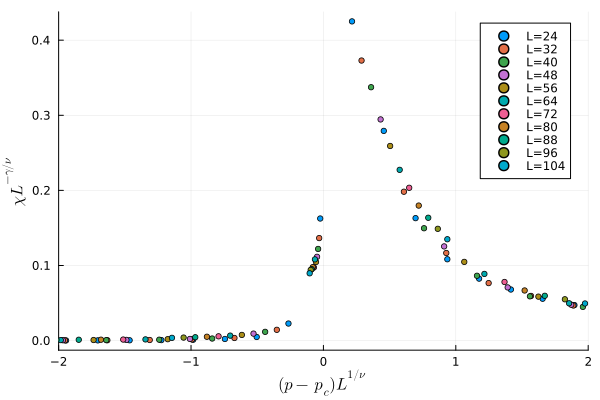

In [274]:
q = 0.1
γ = 1.2
ν = 1.0
pc = 0.091
d  = 2              # <-- set to 1 or 2 depending on your lattice

plt = plot(xlabel = L"(p-p_c)L^{1/\nu}", ylabel = L"\chi L^{-\gamma/\nu}")

for L in 24:8:104
    time(L) = 20L
    ps = collect(0.0:0.01:0.3)

    M1s = [data[("MV", L, 20L, p, q, NaN)][1][time(L)] for p in ps]  # ⟨m⟩
    M2s = [data[("MV", L, 20L, p, q, NaN)][2][time(L)] for p in ps]  # ⟨m^2⟩

    χ  = L^d .* (M2s .- M1s.^2)          # susceptibility from density fluctuations
    x  = (ps .- pc) .* L^(1/ν)
    y  = χ .* L^(-γ/ν)                   # collapse: χ / L^{γ/ν}

    plot!(plt, x, y, label="L=$L", m=3, seriestype=:scatter,xlim=(-2,2))
end

plt

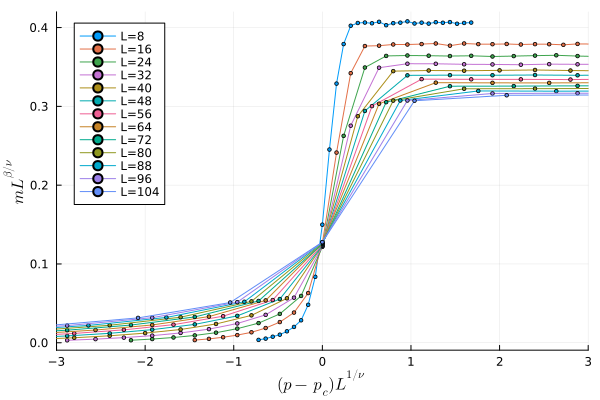

In [219]:
q  = 0.1
pc = 0.09
β  = -0.1
ν  = 1.0

plt = plot(xlabel = L"(p-p_c)L^{1/\nu}", ylabel = L"m L^{\beta/\nu}")

for L in 8:8:104
    ps = collect(0.0:0.01:0.3)

    M1s = [data[("MV", L, 20L, p, q, NaN)][1][20L] for p in ps]  # ⟨m⟩

    x = (ps .- pc) .* L^(1/ν)
    y = M1s .* L^(β/ν)

    plot!(plt, x, y, label="L=$L", m=2, xlims=(-3,3))
end

plt

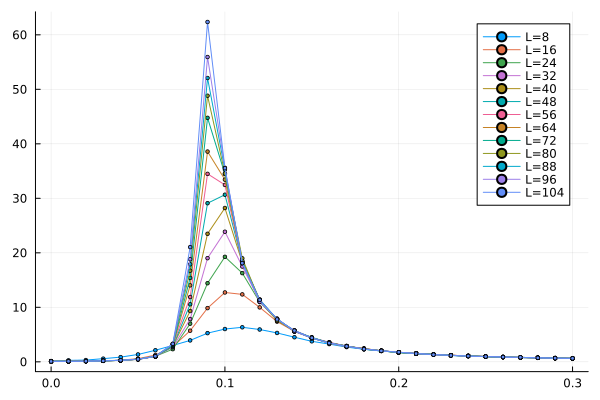

In [87]:
p = 0.1
plt = plot()
for L in 8:8:104
    qs = 0.0:0.01:0.3
    M1s = [data[("MV", L, 20L, p, q, NaN)][1][20L] for q in qs]
    M2s = [data[("MV", L, 20L, p, q, NaN)][2][20L] for q in qs]
    χ = L^2*(M2s .- M1s .^ 2)
    plot!(plt, qs, χ, label="L=$L", m=2)
end
plt

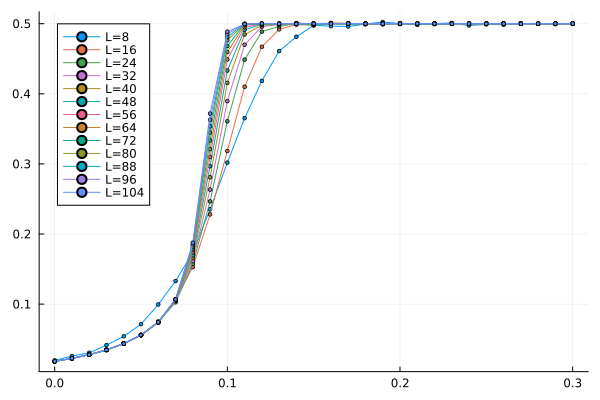

In [88]:
p = 0.1
plt = plot()
for L in 8:8:104
    qs = 0.0:0.01:0.3
    M1s = [data[("MV", L, 20L, p, q, NaN)][1][20L] for q in qs]
    plot!(plt, qs, M1s, label="L=$L", m=2)
end
plt

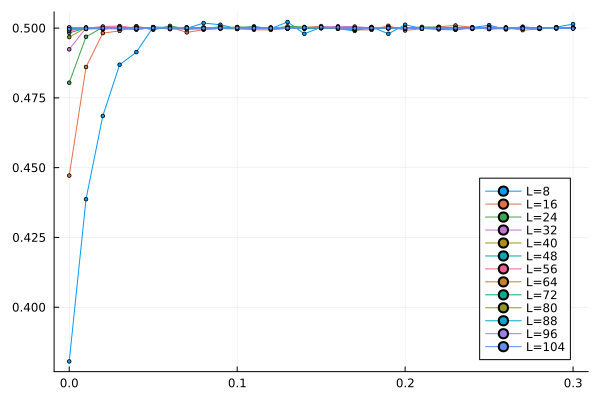

In [289]:
q = 0.25
plt = plot()
for L in 8:8:104
ps = 0.0:0.01:0.3
    M1s = [data[("MV", L, 20L, p, q, NaN)][1][10L] for p in ps]
    plot!(plt, ps, M1s, label="L=$L", m=2)
end
plt

In [98]:
using Graphs
using GraphsMatching

In [291]:
g = complete_graph(4)
w = Dict{Edge,Float64}()
w[Edge(1,4)] = 1.0
w[Edge(2,3)] = 1.0

# find the perfect matching of minimum weight
match = minimum_weight_perfect_matching(g, w)
@assert match.mate[1] == 4
@assert match.mate[4] == 1
@assert match.mate[2] == 3
@assert match.mate[3] == 2

AssertionError: AssertionError: match.mate[1] == 4

In [119]:
g = complete_graph(4)
w = Dict{Edge,Float64}()
w[Edge(1,3)] = 1000.0
w[Edge(1,4)] = 1.0
w[Edge(2,3)] = 1.0
w[Edge(2,4)] = 1000.0
w[Edge(1,2)] = 1000.0
w[Edge(3,4)] = 1000.0

# find the perfect matching of minimum weight
match = minimum_weight_perfect_matching(g, w, 50)
@assert match.mate[1] == 4
@assert match.mate[4] == 1
@assert match.mate[2] == 3
@assert match.mate[3] == 2
@assert match.weight ≈ 1.9

AssertionError: AssertionError: match.mate[1] == 4